## **Deep Neural Network Approaches for Real-Time Single-Cell Antibiotic Susceptibility Prediction**

Dataset Link: https://ora.ox.ac.uk/objects/uuid:12153432-e8b3-4398-a395-abfb980bd84e

#### **Libraries**

In [1]:
import os
import shutil
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
import tensorflow as tf

warnings.filterwarnings('ignore')

In [11]:
shutil.rmtree("Data/MG1655/All_segmentations")

#### **Count of Images from each folder**

**Count of All Images** 

In [2]:
raw_parent_dir = "Data/MG1655/All_images"
folder_names = ['WT+ETOH', 'CIP+ETOH', 'GENT+ETOH', 'RIF+ETOH', 'COAMOX+ETOH']
image_counts = []
for f in folder_names:
    old_name = os.path.join(raw_parent_dir, f)
    new_name = os.path.join(raw_parent_dir, f.split("+")[0])
    os.rename(old_name, new_name)
    count_of_images = len(os.listdir(os.path.join(raw_parent_dir, f.split("+")[0])))
    image_counts.append(count_of_images)
    print(f"{new_name} has {count_of_images} images")

Data/MG1655/All_images\WT has 455 images
Data/MG1655/All_images\CIP has 285 images
Data/MG1655/All_images\GENT has 199 images
Data/MG1655/All_images\RIF has 279 images
Data/MG1655/All_images\COAMOX has 350 images


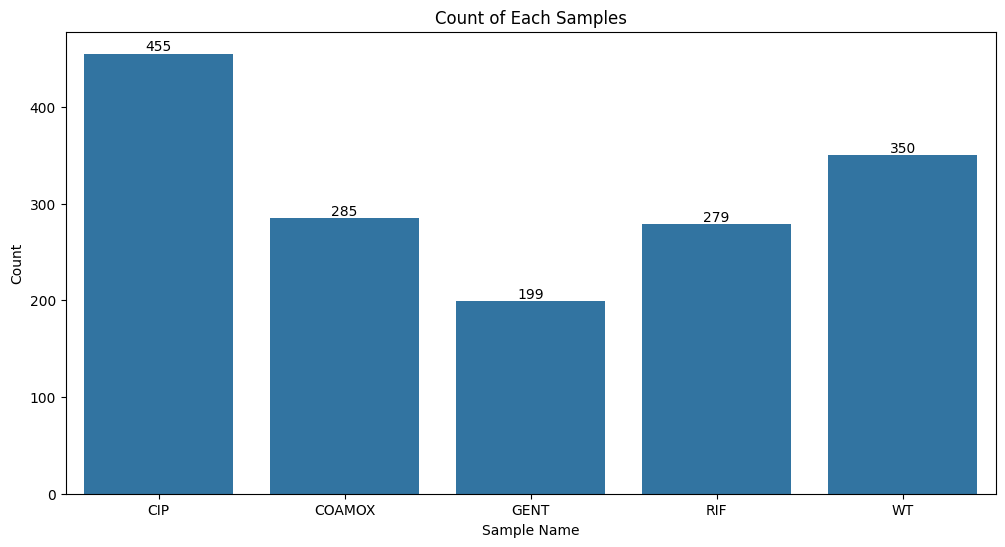

In [5]:
fig = plt.figure(figsize=(12, 6))
ax = sns.barplot(x=os.listdir(raw_parent_dir), y=image_counts)
ax.bar_label(ax.containers[0], fontsize=10)
plt.xlabel("Sample Name")
plt.ylabel("Count")
plt.title("Count of Each Samples")
plt.show()

#### **Complete Data about the tif file**

**Checking on one image file**

In [6]:
from PIL import Image
import tifffile

main_path = os.path.join(raw_parent_dir, "WT/")
img_name = os.listdir(main_path)[0]
print(main_path+img_name)
img_path = os.path.join(main_path, img_name)

print("Image Path:", img_path)

Data/MG1655/All_images\WT/200818_1_MG1655_NA_AMR_combined_1_WT+ETOH_posXY0.tif
Image Path: Data/MG1655/All_images\WT/200818_1_MG1655_NA_AMR_combined_1_WT+ETOH_posXY0.tif


In [7]:
# Information using Pillow library
img_pil = Image.open(img_path)

print("PIL Information")
print("Format:", img_pil.format)
print("Mode:", img_pil.mode)
print("Size (Width x Height):", img_pil.size)

PIL Information
Format: TIFF
Mode: RGB
Size (Width x Height): (420, 684)


* Above information tells us that samples are of `TIFF` and of `RGB` with pixel values `420*684`

In [8]:
# Image information using numpy 
img_array = np.array(img_pil)

print("\nNumPy Information")
print("Shape:", img_array.shape)
print("Data type:", img_array.dtype)
print("Min pixel value:", img_array.min())
print("Max pixel value:", img_array.max())
print("Mean pixel value:", img_array.mean())
print("Std deviation:", img_array.std())


NumPy Information
Shape: (684, 420, 3)
Data type: uint8
Min pixel value: 0
Max pixel value: 255
Mean pixel value: 44.64024180822427
Std deviation: 71.60914369092539


* Shape of (684, 420, 3) suggests that the samples are of 3 channels containing Red, Green and Blue

In [9]:
# Using tiff library
with tifffile.TiffFile(img_path) as tif:
    print("\nTIFF Metadata")
    print("Number of pages:", len(tif.pages))
    print("Image shape:", tif.pages[0].shape)
    print("Image dtype:", tif.pages[0].dtype)
    print("Full metadata:")
    print(tif.pages[0].tags)


TIFF Metadata
Number of pages: 1
Image shape: (3, 684, 420)
Image dtype: uint16
Full metadata:
TiffTag 256 ImageWidth @10 LONG @18 = 420
TiffTag 257 ImageLength @22 LONG @30 = 684
TiffTag 258 BitsPerSample @34 SHORT[3] @194 = (16, 16, 16)
TiffTag 259 Compression @46 SHORT @54 = NONE
TiffTag 262 PhotometricInterpretation @58 SHORT @66 = RGB
TiffTag 270 ImageDescription @70 ASCII[25] @200 = {"shape": [3, 684, 420]}
TiffTag 273 StripOffsets @82 LONG[3] @242 = (304, 574864, 1149424)
TiffTag 277 SamplesPerPixel @94 SHORT @102 = 3
TiffTag 278 RowsPerStrip @106 LONG @114 = 684
TiffTag 279 StripByteCounts @118 LONG[3] @254 = (574560, 574560, 574560)
TiffTag 282 XResolution @130 RATIONAL @266 = (1, 1)
TiffTag 283 YResolution @142 RATIONAL @274 = (1, 1)
TiffTag 284 PlanarConfiguration @154 SHORT @162 = SEPARATE
TiffTag 296 ResolutionUnit @166 SHORT @174 = NONE
TiffTag 305 Software @178 ASCII[12] @282 = tifffile.py


## **For our problem we would be restricting for 2 classes (WT vs CIP)**

#### **Sample image from Each Type**

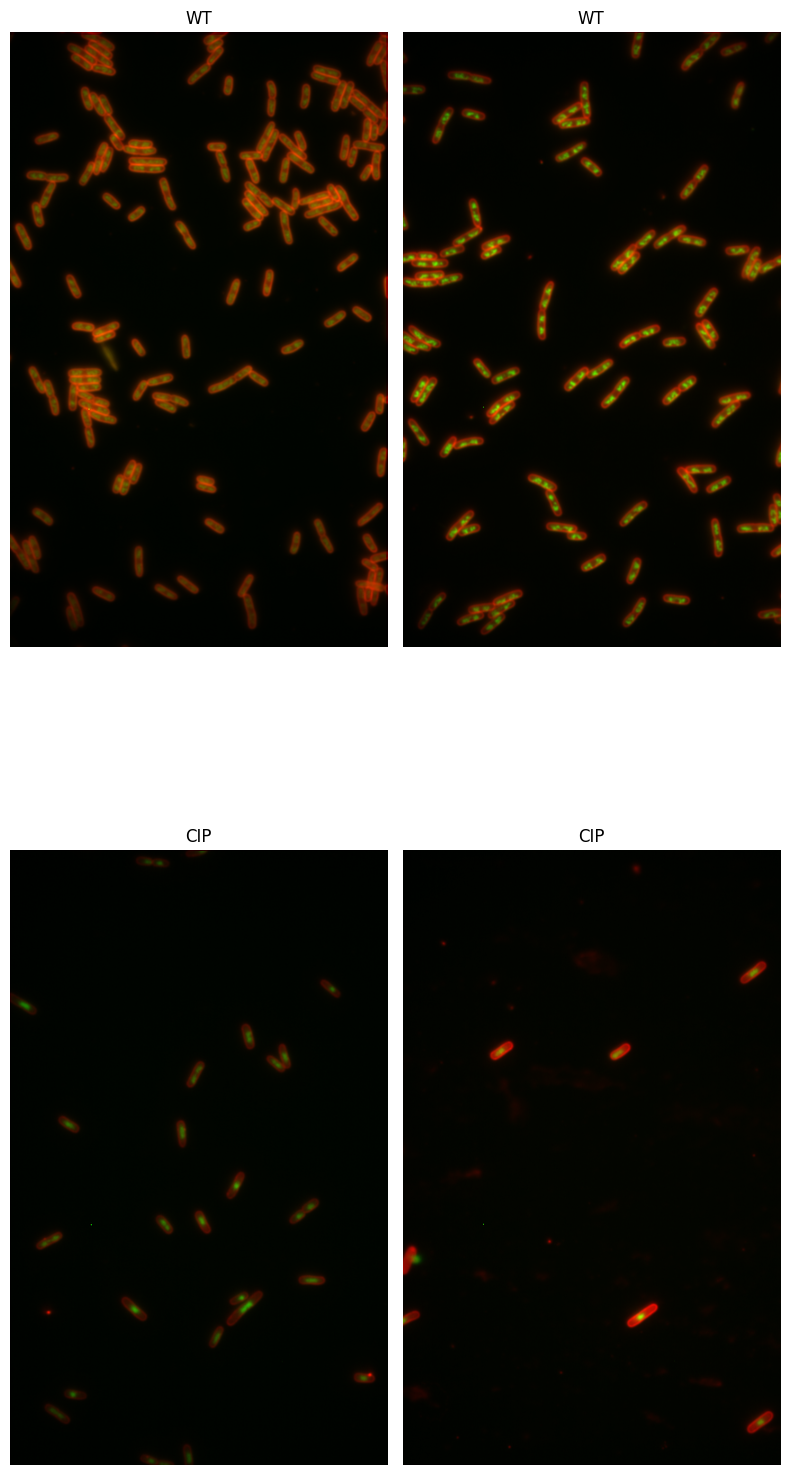

In [ ]:
import random

base_path = raw_parent_dir

classes = ["WT", "CIP"] # WT and choose any other from "GENT", "RIF", "COAMOX"

plt.figure(figsize=(8, 18))

for row, cls in enumerate(classes):
    
    class_path = os.path.join(base_path, cls)
    
    # fetch all files with .tif extension
    images = [f for f in os.listdir(class_path) if f.endswith(".tif")]
    
    # Randomly select 2 images
    selected = random.sample(images, 2)
    
    for col, img_name in enumerate(selected):
        
        img_path = os.path.join(class_path, img_name)
        
        # Load 16-bit image
        img = tifffile.imread(img_path)
        
        # helps in converting (3, H, W) → (H, W, 3)
        img = np.transpose(img, (1, 2, 0))
        
        # Normalization
        img = img.astype(np.float32)
        img = (img - img.min()) / (img.max() - img.min())
        
        plt.subplot(2, 2, row*2 + col + 1)
        plt.imshow(img)
        plt.title(cls)
        plt.axis("off")

plt.tight_layout()
plt.show()

#### **Data Split**

* For splitting data into train, val and test

In [ ]:
# Paths
source_dir = raw_parent_dir
target_dir = "Data Split"

classes = classes

for split in ["train", "val", "test"]:
    for cls in classes:
        os.makedirs(os.path.join(target_dir, split, cls), exist_ok=True)

# Split ratios
train_ratio = 0.7
val_ratio = 0.15
test_ratio = 0.15

for cls in classes:
    class_path = os.path.join(source_dir, cls)
    images = [f for f in os.listdir(class_path) if f.endswith(".tif")]
    
    random.shuffle(images)
    
    total = len(images)
    train_end = int(train_ratio * total)
    val_end = train_end + int(val_ratio * total)
    
    train_imgs = images[:train_end]
    val_imgs = images[train_end:val_end]
    test_imgs = images[val_end:]
    
    # Copy files
    for img in train_imgs:
        shutil.copy2(
            os.path.join(class_path, img),
            os.path.join(target_dir, "train", cls, img)
        )
        
    for img in val_imgs:
        shutil.copy2(
            os.path.join(class_path, img),
            os.path.join(target_dir, "val", cls, img)
        )
        
    for img in test_imgs:
        shutil.copy2(
            os.path.join(class_path, img),
            os.path.join(target_dir, "test", cls, img)
        )

print("Dataset successfully split into Train (70%), Val (15%), Test (15%)")

Dataset successfully split into Train (70%), Val (15%), Test (15%)


#### **Data After Train, Test and Validation split**

In [ ]:
train_parent_dir = r"Data Split/train"
train_folder_names = classes
print("Count of Images for each class in train directory")
for f in train_folder_names:
    count_of_images = len(os.listdir(os.path.join(train_parent_dir, f)))
    print(f"{f} has {count_of_images} images")

Count of Images for each class in train directory
WT has 318 images
CIP has 199 images


In [ ]:
val_parent_dir = "Data Split/val"
val_folder_names = classes
print("Count of Images for each class in val directory")
for f in val_folder_names:
    count_of_images = len(os.listdir(os.path.join(val_parent_dir, f)))
    print(f"{f} has {count_of_images} images")

Count of Images for each class in val directory
WT has 68 images
CIP has 42 images


In [ ]:
test_parent_dir = "Data Split/test"
test_folder_names = classes
print("Count of Images for each class in test directory")
for f in test_folder_names:
    count_of_images = len(os.listdir(os.path.join(test_parent_dir, f)))
    print(f"{f} has {count_of_images} images")

Count of Images for each class in test directory
WT has 69 images
CIP has 44 images


#### **Segmentation**

**Checking Nile Red Index**

Data Split/train\WT/200818_1_MG1655_NA_AMR_combined_1_WT+ETOH_posXY0.tif
Shape: (3, 684, 420)
Dtype: uint16


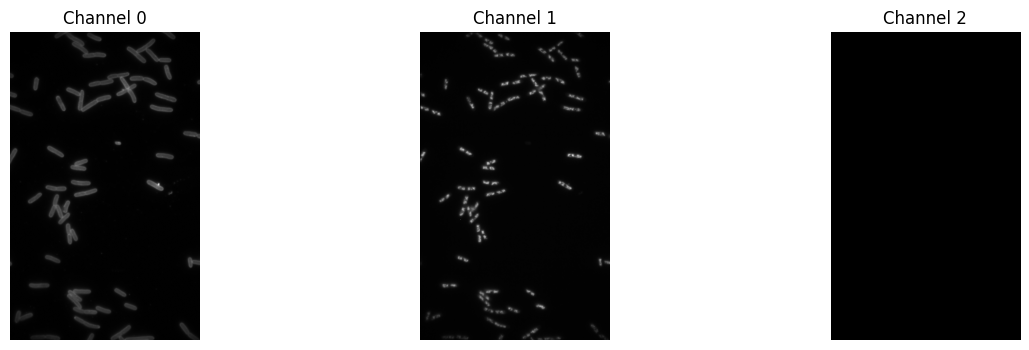

In [16]:
main_path = os.path.join(train_parent_dir, "WT/")
img_name = os.listdir(main_path)[0]
print(main_path+img_name)
img_path = os.path.join(main_path, img_name)

img = tifffile.imread(img_path)

print("Shape:", img.shape)
print("Dtype:", img.dtype)

plt.figure(figsize=(15,4))

for i in range(3):
    channel = img[i]
    channel_norm = cv2.normalize(channel, None, 0, 255, cv2.NORM_MINMAX)
    
    plt.subplot(1,3,i+1)
    plt.imshow(channel_norm, cmap='gray')
    plt.title(f"Channel {i}")
    plt.axis("off")

plt.show()

**Observation: From above plot we can clearly say that Channel 0 separates cells from background. So nile is at index 0**

**Testing on Sample Image from train WT**

Number of detected cells: 29


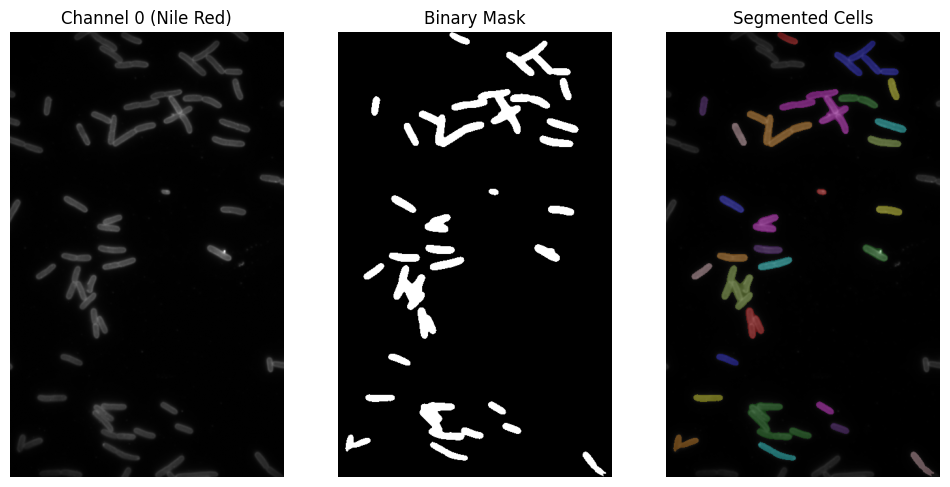

In [ ]:
from skimage import filters, morphology, measure
from skimage.segmentation import clear_border
from skimage.color import label2rgb

img = tifffile.imread(img_path)

nile = img[0]

# Normalize to 0–255
nile_norm = cv2.normalize(nile, None, 0, 255, cv2.NORM_MINMAX)
nile_norm = nile_norm.astype(np.uint8)

# Slight blur
blur = cv2.GaussianBlur(nile_norm, (3,3), 0)

# Otsu threshold
_, binary = cv2.threshold(blur, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
binary = binary > 0

# Remove small noise
binary = morphology.remove_small_objects(binary, min_size=100)
binary = clear_border(binary)

# Label
labels = measure.label(binary)
regions = measure.regionprops(labels)

print("Number of detected cells:", len(regions))

# Overlay
overlay = label2rgb(labels, image=nile_norm, bg_label=0)

plt.figure(figsize=(12,6))

plt.subplot(1,3,1)
plt.imshow(nile_norm, cmap='gray')
plt.title("Channel 0 (Nile Red)")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(binary, cmap='gray')
plt.title("Binary Mask")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(overlay)
plt.title("Segmented Cells")
plt.axis("off")

plt.show()

**Segmenting Train, Val and Test Data**

In [ ]:
# Base dataset path
base_path = "Data Split"

splits = ["train", "val", "test"]
classes = classes

nile_channel_index = 0

for split in splits:
    
    print(f"\nProcessing {split} set...")
    
    input_split_path = os.path.join(base_path, split)
    output_split_path = os.path.join(base_path, f"{split}_segmented")
    
    for cls in classes:
        
        input_class_path = os.path.join(input_split_path, cls)
        output_class_path = os.path.join(output_split_path, cls)
        
        os.makedirs(output_class_path, exist_ok=True)
        
        images = [f for f in os.listdir(input_class_path) if f.endswith(".tif")]
        
        cell_id = 0  # reset per class
        
        for img_name in images:
            
            img_path = os.path.join(input_class_path, img_name)
            
            # Load (3, H, W)
            img = tifffile.imread(img_path)
            
            # Extract Nile channel
            nile = img[nile_channel_index]
            
            # Normalize
            nile = cv2.normalize(nile, None, 0, 255, cv2.NORM_MINMAX)
            nile = nile.astype(np.uint8)
            
            # Blur
            blur = cv2.GaussianBlur(nile, (3,3), 0)
            
            # Otsu threshold
            _, binary = cv2.threshold(
                blur, 0, 255,
                cv2.THRESH_BINARY + cv2.THRESH_OTSU
            )
            
            binary = binary > 0
            
            # Cleanup
            binary = morphology.remove_small_objects(binary, min_size=100)
            binary = morphology.remove_small_holes(binary, area_threshold=100)
            binary = clear_border(binary)
            
            # Label
            labels = measure.label(binary)
            regions = measure.regionprops(labels)
            
            # Convert full image once
            full_img = np.transpose(img, (1,2,0))
            
            for region in regions:
                
                if region.area < 200:
                    continue
                
                minr, minc, maxr, maxc = region.bbox
                cell_crop = full_img[minr:maxr, minc:maxc]
                
                # Optional: resize to fixed size (recommended for CNN)
                cell_crop = cv2.resize(cell_crop, (128,128))
                
                save_name = f"{cls}_{img_name[:-4]}_cell_{cell_id}.png"
                save_path = os.path.join(output_class_path, save_name)
                
                cv2.imwrite(
                    save_path,
                    cv2.cvtColor(cell_crop, cv2.COLOR_RGB2BGR)
                )
                
                cell_id += 1
        
        print(f"{cls}: {cell_id} cells saved")

print("Segmentation complete for train, val, and test.")


Processing train set...
WT: 6841 cells saved
CIP: 4392 cells saved

Processing val set...
WT: 1633 cells saved
CIP: 1086 cells saved

Processing test set...
WT: 1586 cells saved
CIP: 949 cells saved
Segmentation complete for train, val, and test.


**Images Before segmentation**

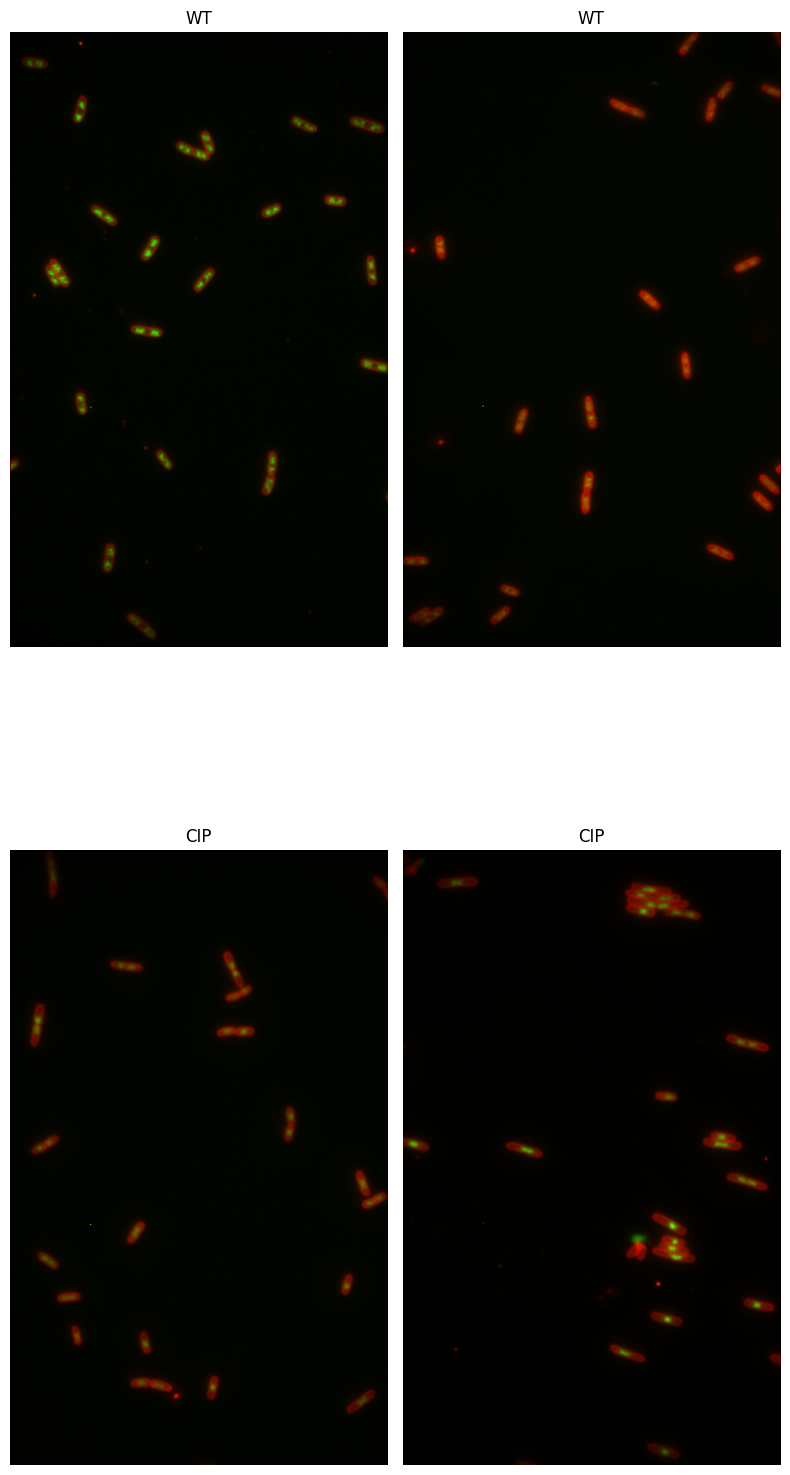

In [ ]:
import random

base_path = "Data Split/train"

classes = classes

plt.figure(figsize=(8, 18))

for row, cls in enumerate(classes):
    
    class_path = os.path.join(base_path, cls)
    
    # fetch all files with .tif extension
    images = [f for f in os.listdir(class_path) if f.endswith(".tif")]
    
    # Randomly select 2 images
    selected = random.sample(images, 2)
    
    for col, img_name in enumerate(selected):
        
        img_path = os.path.join(class_path, img_name)
        
        # Load 16-bit image
        img = tifffile.imread(img_path)
        
        # helps in converting (3, H, W) → (H, W, 3)
        img = np.transpose(img, (1, 2, 0))
        
        # Normalization
        img = img.astype(np.float32)
        img = (img - img.min()) / (img.max() - img.min())
        
        plt.subplot(2, 2, row*2 + col + 1)
        plt.imshow(img)
        plt.title(cls)
        plt.axis("off")

plt.tight_layout()
plt.show()

**Segmented Images in Train**

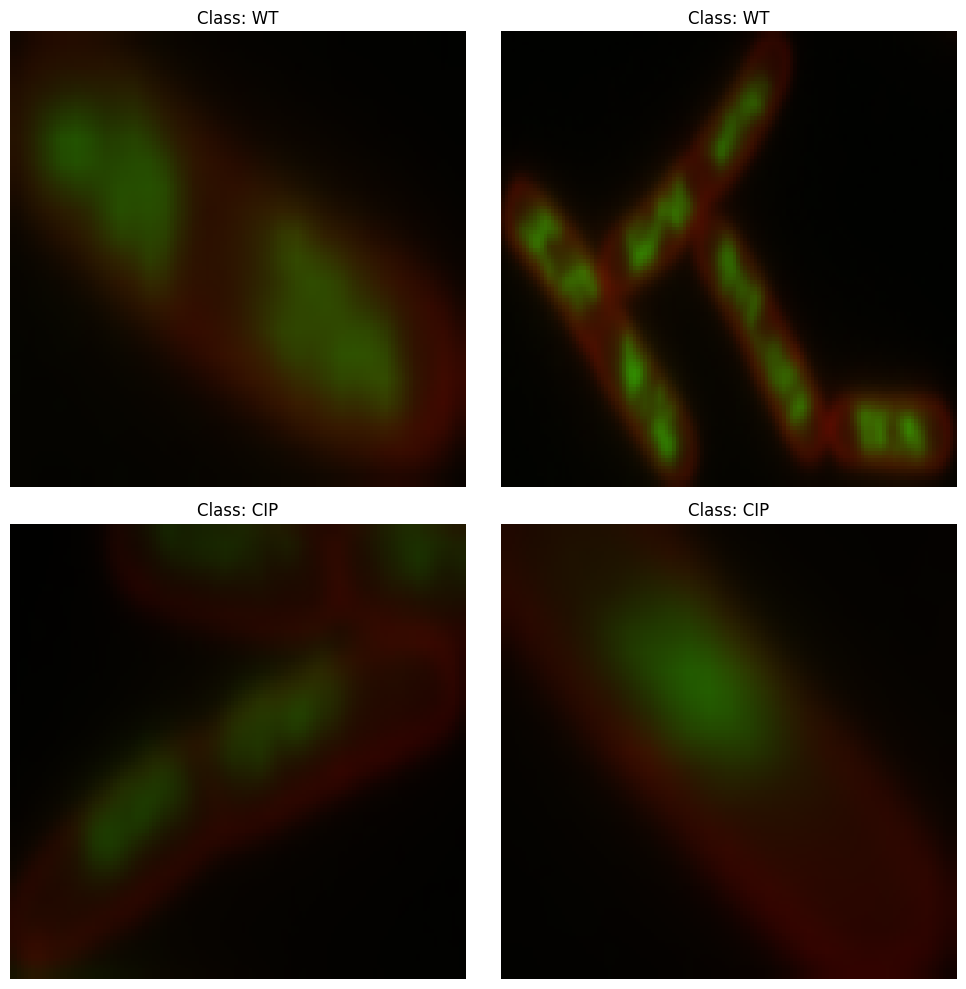

In [ ]:
import matplotlib.image as mpimg

data_dir = 'Data Split/train_segmented'
classes = classes

selected_images = []

for cls in classes:
    cls_path = os.path.join(data_dir, cls)
    
    # Get all images and sort them (important for consistent order)
    images = sorted(os.listdir(cls_path))
    
    # Take first 2 images
    first_two = images[:2]
    
    # Add full paths
    for img_name in first_two:
        selected_images.append(os.path.join(cls_path, img_name))

plt.figure(figsize=(10, 10))

for i in range(len(selected_images)):
    plt.subplot(2, 2, i + 1)
    
    img = mpimg.imread(selected_images[i])
    plt.imshow(img)
    
    # Extract class name safely
    title = os.path.basename(os.path.dirname(selected_images[i]))
    plt.title(f"Class: {title}")
    plt.axis('off')

plt.tight_layout()
plt.show()

#### **Models**